# What does an energy community pay, and under which tariff?

Fifty households are drawn from four Fluvius datasets and treated as one energy community.
Some have PV, some add an EV or a heat pump, ten have a 30 kWh battery. The whole community
is settled over the full year under four commercial arrangements:

| Scenario | PV owners | Everyone else |
|---|---|---|
| **Redni** | `GENI_SAMO_REDNI` (samooskrba) | `GENI_REDNI` (dobava) |
| **Aktivni** | `GENI_SAMO_AKTIVNI` (4-tariff) | `GENI_AKTIVNI` |
| **Dinamični** | `GENI_SAMO_DINAMICNI` (SIPX + pribitek) | `GENI_DINAMICNI` |
| **Souporaba** | oddajniki, 40 % of surplus shared | prejemniki |

Two price lists per scenario because `si_paketi.preveri_paket` rejects a samooskrba list for
a household with no PV device, so the plain households take the supplier's plain supply twin
of the same list.

The four questions: what the community pays as a whole, split into energy / network / fixed /
credit; its annual peak power against the sum of the individual peaks; who the extremes are;
and how much of the answer depends on owning a battery.

In [1]:
### Imports
import importlib
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter

import Community_Study as cs
cs = importlib.reload(cs)

print("Community_Study loaded.")

Community_Study loaded.


## 1. Configuration

In [2]:
### Study configuration, read from the module
MEMBERS = cs.build_community()
RUN_DISPATCH = False       # True -> re-solve the battery households (~5 min on 10 workers)
N_WORKERS = 10

battery_members = [m for m in MEMBERS if m.has_battery]

print(f"{'Members':24s}{len(MEMBERS)}")
for dataset, ids, has_pv, battery_ids in cs.COMMUNITY_SPEC:
    ids = list(ids)
    print(f"{'  ' + dataset:24s}{len(ids):3d} households"
          f"{'  PV' if has_pv else '    '}"
          f"{'  ' + str(len(battery_ids)) + ' x 30 kWh battery' if battery_ids else ''}")
print(f"{'Batteries':24s}{len(battery_members)} x {cs.BATTERY_CAPACITY_KWH:.0f} kWh"
      f"  (C-rate {cs.C_RATE}, eta {cs.CHARGE_EFFICIENCY})")
print(f"{'Community battery':24s}{cs.COMMUNITY_BATTERY_KWH:.0f} kWh (not modelled)")
print(f"{'Pricing year':24s}{cs.PRICING_REFERENCE_YEAR}")
print(f"{'Peak reset':24s}{cs.PEAK_RESET_MONTHS}")
print(f"{'Solver gap / limit':24s}{cs.hc.FULL_PERIOD_GAP_REL} / {cs.hc.FULL_PERIOD_TIME_LIMIT_S}s")
print(f"{'Souporaba':24s}delez {cs.SOUPORABA_DELEZ:.0%}, "
      f"cena {cs.SOUPORABA_CENA_EUR_KWH} EUR/kWh, {cs.SOUPORABA_SERVICE_ID}")
print()
for name, cfg in cs.SCENARIOS.items():
    print(f"  {cfg['label']:12s} PV: {cfg['pv_paket']:22s} other: {cfg['nonpv_paket']}")

Members                 50
  Fluvius                20 households    
  Fluvius_PV             10 households  PV  5 x 30 kWh battery
  Fluvius_PV_EV          10 households  PV
  Fluvius_PV_HP          10 households  PV  5 x 30 kWh battery
Batteries               10 x 30 kWh  (C-rate 0.5, eta 0.95)
Community battery       0 kWh (not modelled)
Pricing year            2026
Peak reset              1
Solver gap / limit      0.001 / 900s
Souporaba               delez 40%, cena 0.05 EUR/kWh, GENI_SOUPORABA

  Redni        PV: GENI_SAMO_REDNI        other: GENI_REDNI
  Aktivni      PV: GENI_SAMO_AKTIVNI      other: GENI_AKTIVNI
  Dinamicni    PV: GENI_SAMO_DINAMICNI    other: GENI_DINAMICNI
  Souporaba    PV: GENI_SAMO_DINAMICNI    other: GENI_DINAMICNI


## 2. Build the community

In [3]:
### Load every member and compute its contracted power
t0 = time.time()
MEMBERS, DATA = cs.load_community(MEMBERS)
print(f"Loaded {len(DATA)} households in {time.time() - t0:.1f}s")

roster = pd.DataFrame([
    {
        "household_id": m.key,
        "segment": m.segment,
        "PV": m.has_pv,
        "Battery_kWh": m.battery_kwh,
        "Consumed_kWh": float(DATA[m.key][cs.CONSUMPTION_COLUMN].sum()),
        "Produced_kWh": float(DATA[m.key][cs.GENERATION_COLUMN].sum()),
        "Contracted_kW": m.contracted_power_kw[2],
    }
    for m in MEMBERS
])

print(f"\nIntervals per household: {set(len(d) for d in DATA.values())}")
print(f"Period: {next(iter(DATA.values())).index.min()} -> "
      f"{next(iter(DATA.values())).index.max()}")
roster.groupby("segment").agg(
    N=("household_id", "count"),
    Consumed_MWh=("Consumed_kWh", lambda s: s.sum() / 1000),
    Produced_MWh=("Produced_kWh", lambda s: s.sum() / 1000),
    Mean_Contracted_kW=("Contracted_kW", "mean"),
    Batteries=("Battery_kWh", lambda s: int((s > 0).sum())),
).round(2)

Loaded 50 households in 17.2s

Intervals per household: {35136}
Period: 2024-01-01 00:00:00+00:00 -> 2024-12-31 23:45:00+00:00


,N,Consumed_MWh,Produced_MWh,Mean_Contracted_kW,Batteries
segment,,,,,
Fluvius,20,60.30,0.00,3.79,0
Fluvius_PV,10,20.39,24.40,3.86,5
Fluvius_PV_EV,10,42.23,27.65,7.00,0
Fluvius_PV_HP,10,36.46,19.84,5.07,5


In [4]:
### Verification 1 + 2 -- data sanity and package validity
import sys
sys.path.append("New pricing functions")
from si_paketi import Gospodinjstvo, PAKETI, Shema, preveri_paket

lengths = {len(d) for d in DATA.values()}
smp_max = max(float(d[cs.PRICE_COLUMN].abs().quantile(0.95)) for d in DATA.values())
nans = sum(int(d[cs.PRICE_COLUMN].isna().sum()) for d in DATA.values())
assert len(lengths) == 1, f"ragged histories: {lengths}"
assert smp_max < 2.0, f"SMP looks like EUR/MWh, not EUR/kWh (q95={smp_max})"
assert nans == 0, f"{nans} NaN prices"

failures = []
for m in MEMBERS:
    g = Gospodinjstvo(m.key, m.contracted_power_kw, ima_pv=m.has_pv,
                      shema_samooskrbe=Shema.NOVA if m.has_pv else Shema.BREZ,
                      meritve_15min=True)
    for scenario in cs.SCENARIOS:
        paket = PAKETI[cs.scenario_paket(scenario, m)]
        try:
            preveri_paket(paket, g, strogo=True)
        except Exception as exc:
            failures.append((m.key, scenario, repr(exc)))

print(f"1. {len(DATA)} households x {lengths.pop()} intervals, "
      f"SMP q95 {smp_max:.4f} EUR/kWh, {nans} NaNs -> OK")
print(f"2. {len(MEMBERS) * len(cs.SCENARIOS)} (household, scenario) package pairs, "
      f"{len(failures)} rejected by preveri_paket -> "
      f"{'OK' if not failures else 'FAILED'}")
for f in failures[:5]:
    print("   ", f)

1. 50 households x 35136 intervals, SMP q95 0.1716 EUR/kWh, 0 NaNs -> OK
2. 200 (household, scenario) package pairs, 0 rejected by preveri_paket -> OK


## 3. Battery dispatch

The ten battery households are dispatched by `MILP_Benchmark.run_milp_benchmark`, whole year,
opening and closing at 50 % SOC, solved to `FULL_PERIOD_GAP_REL`. The `souporaba` scenario
reuses the `dinamicni` dispatch. Each trajectory is reduced to the equivalent (consumption,
generation) pair that reproduces its net grid flow exactly.

In [5]:
### Solve or load the dispatch cache
if RUN_DISPATCH:
    cs.run_batch_dispatch(MEMBERS, n_workers=N_WORKERS)

cached = sorted(cs.DISPATCH_DIR.glob("*.csv"))
expected = cs.dispatch_units(MEMBERS)
print(f"{len(cached)} cached trajectories, {len(expected)} expected.")
if len(cached) < len(expected):
    raise SystemExit(
        "Dispatch cache incomplete. Set RUN_DISPATCH = True, or run\n"
        "    .venv/bin/python Community_Study.py --workers 10"
    )

balance = cs.check_dispatch_balance()
print("\nVerification 3 -- SOC recursion, bounds, curtailment, exclusivity")
print(f"  max |SOC residual|      {balance['Max_SOC_Residual_kWh'].max():.2e} kWh")
print(f"  SOC within [0, cap]     {balance['SOC_in_Bounds'].all()}")
print(f"  spill <= generation     {balance['Spill_within_Generation'].all()}")
print(f"  no simultaneous ch/dis  {balance['No_Simultaneous_ChDis'].all()}")
print(f"  -> {'OK' if balance['OK'].all() else 'FAILED'}")

drift = balance["SOC_Drift_kWh"].abs().max()
print(f"\n  max |SOC drift| over the year {drift:.3f} kWh "
      f"({100 * drift / cs.BATTERY_CAPACITY_KWH:.2f} % of capacity)")
print("  The terminal SOC is a floor (E[N] >= 50 %), not an equality, so a solve may")
print("  finish slightly above where it started. Any such surplus is stored energy the")
print("  household paid for and did not use -- it flatters the battery, never the")
print("  reverse, and at this magnitude it is far below the 0.1 % solver gap.")

30 cached trajectories, 30 expected.



Verification 3 -- SOC recursion, bounds, curtailment, exclusivity
  max |SOC residual|      1.00e-06 kWh
  SOC within [0, cap]     True
  spill <= generation     True
  no simultaneous ch/dis  True
  -> OK

  max |SOC drift| over the year 0.137 kWh (0.46 % of capacity)
  The terminal SOC is a floor (E[N] >= 50 %), not an equality, so a solve may
  finish slightly above where it started. Any such surplus is stored energy the
  household paid for and did not use -- it flatters the battery, never the
  reverse, and at this magnitude it is far below the 0.1 % solver gap.


## 4. Settlement

Scenarios 1–3 are priced interval by interval through `calculate_interval_price`; `souporaba`
goes through `si_obracun.obracun_souporabe`, settled month by month and summed, because the
power charge, the OVE/SPTE contribution and the excess-power penalty all reset monthly.

Every scenario is settled a second time with `no_battery=True` over the same horizon
(`cs.dispatch_horizon`). That pass is the baseline every figure in section 8 is drawn
against.

In [6]:
### Settle all four scenarios
t0 = time.time()
RESULTS = cs.run_all_scenarios(MEMBERS, DATA, verbose=True)
print(f"\nAll scenarios settled in {time.time() - t0:.1f}s")

PROFILES = {s: cs.scenario_profiles(MEMBERS, DATA, s) for s in cs.SCENARIOS}
HOUSEHOLDS = cs.per_household(RESULTS)

cs.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
HOUSEHOLDS.to_csv(cs.RESULTS_DIR / "per_household.csv", index=False)
print(f"{len(HOUSEHOLDS)} (scenario, household) rows -> "
      f"{cs.RESULTS_DIR / 'per_household.csv'}")

--- redni ---


    settled in 81.8s


--- aktivni ---


    settled in 82.3s


--- dinamicni ---


...

  souporaba 2024-11 settled


  souporaba 2024-12 settled


    settled in 12.3s



All scenarios settled in 259.0s


200 (scenario, household) rows -> /Users/summerscholl/Documents/Andraz/Energy_Community/Results/Community_Study/per_household.csv


In [7]:
### The same year with the batteries taken out -- the baseline
# Same households, load, PV, contracted power, price list and horizon; only the
# ten 30 kWh batteries are removed.
t0 = time.time()
BASELINE = cs.run_all_scenarios(MEMBERS, DATA, no_battery=True, verbose=True)
print(f"\nBaseline settled in {time.time() - t0:.1f}s")

TOTALS_BASE = cs.community_totals(BASELINE)
HOUSEHOLDS_BASE = cs.per_household(BASELINE)

# With no battery the net flow is the raw metered load, so one baseline curve
# covers all four scenarios.
ref_flow = BASELINE["redni"]["community_profile"]["community_import_kw"].to_numpy(dtype=float)
for scenario in cs.SCENARIOS:
    flow = BASELINE[scenario]["community_profile"]["community_import_kw"].to_numpy(dtype=float)
    assert np.array_equal(flow, ref_flow), f"baseline flow differs under {scenario}"
    assert len(BASELINE[scenario]["community_profile"]) == \
        len(RESULTS[scenario]["community_profile"]), f"horizon mismatch under {scenario}"
BASE_PROFILE = BASELINE["redni"]["community_profile"]

print(f"\nBaseline flow identical in all {len(cs.SCENARIOS)} scenarios, "
      f"{len(BASE_PROFILE):,} intervals, settled over the same horizon as the "
      f"dispatched run.")
print(f"Community peak with no batteries: "
      f"{BASE_PROFILE['community_import_kw'].max():.1f} kW")

TOTALS_BASE[["Scenario", "Total_EUR", "EUR_per_MWh", "Community_Peak_kW"]].rename(columns={
    "Total_EUR": "Brez baterij [EUR/a]",
    "EUR_per_MWh": "Brez baterij [EUR/MWh]",
    "Community_Peak_kW": "Konica brez baterij [kW]",
}).round(2)

--- redni (no battery) ---


    settled in 81.4s


--- aktivni (no battery) ---


    settled in 81.7s


--- dinamicni (no battery) ---


...

  souporaba 2024-11 settled


  souporaba 2024-12 settled


    settled in 11.6s



Baseline settled in 256.7s

Baseline flow identical in all 4 scenarios, 35,135 intervals, settled over the same horizon as the dispatched run.
Community peak with no batteries: 63.0 kW


,Scenario,Brez baterij [EUR/a],Brez baterij [EUR/MWh],Konica brez baterij [kW]
0,Redni,30324.85,190.28,63.02
1,Aktivni,34013.11,213.42,63.02
2,Dinamicni,30836.96,193.49,63.02
3,Souporaba,35110.62,220.31,63.02


## 5. The community as a whole

In [8]:
### What the community pays, per scenario
TOTALS = cs.community_totals(RESULTS)

totals_display = TOTALS[[
    "Scenario", "Total_EUR", "EUR_per_MWh", "Variable_Gross_EUR",
    "Fixed_EUR", "Credit_EUR", "Consumed_MWh",
]].rename(columns={
    "Total_EUR": "Total [EUR/a]",
    "EUR_per_MWh": "Unit [EUR/MWh]",
    "Variable_Gross_EUR": "Energy + network [EUR]",
    "Fixed_EUR": "Fixed [EUR]",
    "Credit_EUR": "Export credit [EUR]",
    "Consumed_MWh": "Consumed [MWh]",
})
print("Gross bill minus export credit. The samooskrba path nets the export inside")
print("the interval and the souporaba path deducts it after VAT, so both are put on")
print("a common gross basis; the reconciliation is checked in the next cell.")
totals_display.round(2)

Gross bill minus export credit. The samooskrba path nets the export inside
the interval and the souporaba path deducts it after VAT, so both are put on
a common gross basis; the reconciliation is checked in the next cell.


,Scenario,Total [EUR/a],Unit [EUR/MWh],Energy + network [EUR],Fixed [EUR],Export credit [EUR],Consumed [MWh]
0,Redni,29437.35,184.71,22931.74,9702.01,3196.40,159.37
1,Aktivni,27601.78,173.19,29717.97,9702.01,11818.20,159.37
2,Dinamicni,23542.40,147.72,26917.49,10419.35,13794.43,159.37
3,Souporaba,39549.39,248.16,27557.74,22420.97,10429.32,159.37


In [9]:
### Community peak power over the year
peak_display = TOTALS[[
    "Scenario", "Community_Peak_kW", "Peak_At",
    "Sum_Individual_Peaks_kW", "Diversity_Factor",
]].rename(columns={
    "Community_Peak_kW": "Coincident peak [kW]",
    "Peak_At": "Occurs at (UTC)",
    "Sum_Individual_Peaks_kW": "Sum of individual peaks [kW]",
    "Diversity_Factor": "Diversity factor",
})

peak_check = cs.check_community_peak(RESULTS)
print("Verification 5 -- coincident peak <= sum of individual peaks, "
      f"timestamp reproduces: {peak_check['OK'].all() and peak_check['Timestamp_Reproduces'].all()}")
print("\nThe coincident peak is what the community's shared connection sees. The regulated")
print("power charge is billed per household per tariff block, so it is the RIGHT-hand column")
print("that drives the bill -- the gap between them is the value the community never captures.")
peak_display.round(3)

Verification 5 -- coincident peak <= sum of individual peaks, timestamp reproduces: True

The coincident peak is what the community's shared connection sees. The regulated
power charge is billed per household per tariff block, so it is the RIGHT-hand column
that drives the bill -- the gap between them is the value the community never captures.


/var/folders/39/ydgffyrd3m102wzr66n24xmr0000gr/T/ipykernel_75457/166413377.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  peak_display.round(3)


,Scenario,Coincident peak [kW],Occurs at (UTC),Sum of individual peaks [kW],Diversity factor
0,Redni,63.016,2024-01-06 13:30:00+00:00,303.305,0.208
1,Aktivni,152.522,2024-01-06 14:45:00+00:00,376.342,0.405
2,Dinamicni,152.839,2024-01-29 00:00:00+00:00,385.589,0.396
3,Souporaba,152.839,2024-01-29 00:00:00+00:00,385.589,0.396


In [10]:
### Energy balance of the community
cs.community_kpis(RESULTS).drop(columns=["scenario"]).round(2)

,Scenario,Consumed_MWh,Produced_MWh,Imported_MWh,Exported_MWh,Self_Sufficiency_pct,Self_Consumption_pct
0,Redni,159.37,71.89,147.80,59.30,7.90,17.51
1,Aktivni,159.37,71.89,209.58,113.71,-26.24,-58.17
2,Dinamicni,159.37,71.89,203.81,107.63,-22.43,-49.73
3,Souporaba,159.37,71.89,203.81,107.63,-22.43,-49.73


## 6. Who pays what

In [11]:
### Mean annual cost by segment and battery status
cs.by_segment(RESULTS).round(2)

,Scenario,segment,battery,N,Mean_EUR,Min_EUR,Max_EUR
0,Aktivni,Fluvius,no battery,20,647.13,190.10,2300.53
1,Aktivni,Fluvius_PV,battery,5,-297.38,-451.58,-100.33
2,Aktivni,Fluvius_PV,no battery,5,501.40,305.63,1022.25
3,Aktivni,Fluvius_PV_EV,no battery,10,936.06,442.62,1593.33
4,Aktivni,Fluvius_PV_HP,battery,5,258.20,-109.38,510.42
5,Aktivni,Fluvius_PV_HP,no battery,5,597.49,441.25,763.11
6,Dinamicni,Fluvius,no battery,20,630.91,202.96,2129.97
7,Dinamicni,Fluvius_PV,battery,5,-440.90,-577.74,-285.05
8,Dinamicni,Fluvius_PV,no battery,5,411.77,254.59,770.35
9,Dinamicni,Fluvius_PV_EV,no battery,10,801.96,325.04,1388.61


In [12]:
### Cheapest scenario for each household
pivot = HOUSEHOLDS.pivot_table(
    index=["segment", "household_id"], columns="Scenario", values="total_cost_eur"
)
order = [cs.SCENARIOS[s]["label"] for s in cs.SCENARIOS]
pivot = pivot.reindex(columns=order)
pivot["Best"] = pivot.idxmin(axis=1)
pivot["Spread [EUR]"] = pivot[order].max(axis=1) - pivot[order].min(axis=1)

print("How many households are cheapest under each scenario:")
print(pivot["Best"].value_counts().to_string())
pivot.round(2)

How many households are cheapest under each scenario:
Best
Dinamicni    24
Redni        21
Aktivni       5


Scenario                           Redni  Aktivni  Dinamicni  Souporaba  \
segment       household_id                                                
Fluvius       Fluvius_001         517.42   514.78     523.11     586.65   
              Fluvius_002         585.57   550.76     564.39     635.12   
              Fluvius_003         632.78   632.16     631.99     696.91   
              Fluvius_004         587.66   586.98     588.84     636.19   
              Fluvius_005         188.14   190.10     202.96     343.67   
              Fluvius_006         501.57   495.69     493.53     565.17   
              Fluvius_007         883.28   870.90     872.43     880.95   
              Fluvius_008         552.34   573.38     571.15     630.96   
              Fluvius_009         510.20   535.93     524.63     596.85   
              Fluvius_010         769.19   798.99     770.64     805.42   
              Fluvius_011         438.23   416.94     434.55     529.30   
              Fluvius_012         503.89   499.81     496.62     558.99   
              Fluvius_013        2234.38  2300.53    2129.97    2207.40   
              Fluvius_014         313.89   316.60     322.31     429.71   
              Fluvius_015         245.74   255.38     261.61     389.91   
              Fluvius_016         992.85  1069.86     947.19    1070.55   
              Fluvius_017         698.85   709.47     692.84     728.85   
              Fluvius_018         755.87   791.60     755.34     810.41   
              Fluvius_019         470.76   475.85     474.40     541.98   
              Fluvius_020         345.01   356.91     359.64     460.31   
Fluvius_PV    Fluvius_PV_001      349.85  -100.33    -285.05     648.18   
              Fluvius_PV_002      136.23  -340.17    -481.79     813.36   
              Fluvius_PV_003       49.51  -451.58    -577.74     810.04   
              Fluvius_PV_004      231.41  -229.05    -348.97    1150.28   
              Fluvius_PV_005      132.52  -365.77    -510.94     774.23   
              Fluvius_PV_006      807.48  1022.25     770.35     987.89   
              Fluvius_PV_007      260.84   325.23     254.59     347.26   
              Fluvius_PV_008      448.87   520.04     486.82     566.91   
              Fluvius_PV_009      276.03   305.63     259.92     360.30   
              Fluvius_PV_010      299.00   333.83     287.17     385.30   
Fluvius_PV_EV Fluvius_PV_EV_001   924.98  1133.02     965.99    1069.89   
              Fluvius_PV_EV_002   517.19   582.13     543.51     626.48   
              Fluvius_PV_EV_003  1041.83  1199.18    1050.72    1224.76   
              Fluvius_PV_EV_004   453.28   561.89     480.87     566.95   
              Fluvius_PV_EV_005   695.18   802.76     714.87     809.76   
              Fluvius_PV_EV_006  1002.42  1365.21    1120.33    1205.47   
              Fluvius_PV_EV_007   852.89  1062.24     918.38    1027.68   
              Fluvius_PV_EV_008   480.51   618.19     511.24     619.21   
              Fluvius_PV_EV_009  1372.09  1593.33    1388.61    1530.10   
              Fluvius_PV_EV_010   367.32   442.62     325.04     572.89   
Fluvius_PV_HP Fluvius_PV_HP_001   709.89   313.09     125.26    1466.99   
              Fluvius_PV_HP_002   660.98   281.71      81.16    1474.70   
              Fluvius_PV_HP_003   894.83   510.42     272.77    1523.89   
              Fluvius_PV_HP_004   762.00   295.16     146.75     959.91   
              Fluvius_PV_HP_005   335.97  -109.38    -280.26     713.22   
              Fluvius_PV_HP_006   566.39   700.63     623.89     708.38   
              Fluvius_PV_HP_007   405.23   441.25     404.58     510.30   
              Fluvius_PV_HP_008   653.33   763.11     672.19     764.17   
              Fluvius_PV_HP_009   539.66   526.19     498.72     617.74   
              Fluvius_PV_HP_010   481.99   556.27     505.28     607.84   

Scenario                              Best  Spread [EUR]  
segment       household_id              

In [13]:
### Verification 4 -- a battery must never make the bill worse
COUNTERFACTUAL = cs.battery_counterfactual(MEMBERS, DATA, RESULTS)
violations = COUNTERFACTUAL[COUNTERFACTUAL["Saving_EUR"] < 0]
print(f"{len(COUNTERFACTUAL)} (battery household, scenario) pairs re-settled at 0 kWh; "
      f"{len(violations)} where the battery lost money -> "
      f"{'OK' if violations.empty else 'FAILED'}")
if not violations.empty:
    display(violations)

COUNTERFACTUAL.groupby("Scenario")[["No_Battery_EUR", "With_Battery_EUR", "Saving_EUR"]] \
    .agg(["mean", "min", "max"]).round(2)

30 (battery household, scenario) pairs re-settled at 0 kWh; 0 where the battery lost money -> OK


No_Battery_EUR                  With_Battery_EUR                  \
                    mean     min      max             mean     min     max   
Scenario                                                                     
Aktivni           621.54  176.85  1164.29           -19.59 -451.58  510.42   
Dinamicni         543.57  123.73  1016.84          -185.88 -577.74  272.77   
Redni             515.07  122.03   969.13           426.32   49.51  894.83   

          Saving_EUR                  
                mean     min     max  
Scenario                              
Aktivni       641.13  516.94  708.45  
Dinamicni     729.46  637.17  790.68  
Redni          88.75   27.89  141.03

## 7. The extremes

The cheapest and the dearest household in each scenario, and what is driving each.

In [14]:
### Highest- and lowest-cost household per scenario
EXTREMES = cs.extremes(RESULTS)
EXTREMES[[
    "Scenario", "Extreme", "household_id", "segment", "Cost_EUR", "EUR_per_MWh",
    "Consumed_kWh", "Produced_kWh", "Battery_kWh", "Contracted_kW", "Peak_kW",
    "Peak_over_Contract",
]].round(2)

,Scenario,Extreme,household_id,segment,Cost_EUR,EUR_per_MWh,Consumed_kWh,Produced_kWh,Battery_kWh,Contracted_kW,Peak_kW,Peak_over_Contract
0,Redni,lowest,Fluvius_PV_003,Fluvius_PV,49.51,44.17,1121.00,2728.03,30.0,2.23,1.83,0.82
1,Redni,highest,Fluvius_013,Fluvius,2234.38,179.86,12422.63,0.00,0.0,7.27,9.81,1.35
2,Aktivni,lowest,Fluvius_PV_003,Fluvius_PV,-451.58,-402.83,1121.00,2728.03,30.0,2.23,11.42,5.11
3,Aktivni,highest,Fluvius_013,Fluvius,2300.53,185.19,12422.63,0.00,0.0,7.27,9.81,1.35
4,Dinamicni,lowest,Fluvius_PV_003,Fluvius_PV,-577.74,-515.38,1121.00,2728.03,30.0,2.23,11.75,5.26
5,Dinamicni,highest,Fluvius_013,Fluvius,2129.97,171.46,12422.63,0.00,0.0,7.27,9.81,1.35
6,Souporaba,lowest,Fluvius_005,Fluvius,343.67,468.21,734.00,0.00,0.0,1.31,3.80,2.90
7,Souporaba,highest,Fluvius_013,Fluvius,2207.40,177.69,12422.63,0.00,0.0,7.27,9.81,1.35


In [15]:
### Souporaba: what was shared, used and forfeited
sou = RESULTS["souporaba"]["summary"]
sou_members = sou[sou["household_id"] != "GROUP"]

conservation = cs.check_souporaba_conservation(RESULTS["souporaba"])
print(f"Verification 6 -- shared energy conserved every month: "
      f"{conservation['OK'].all()}")
print(f"  max residual {conservation['Residual_kWh'].abs().max():.3f} kWh "
      f"vs rounding bound {conservation['Rounding_Bound_kWh'].max():.3f} kWh")
print("  (si_obracun rounds every diagnostic to 2 dp, so the balance cannot close")
print("   exactly; the bound is 0.005 kWh x the number of rounded figures)")

shared = float(sou_members.loc[sou_members["role"] == "oddajnik", "deljeno_kwh"].sum())
used = float(sou_members.loc[sou_members["role"] == "prejemnik", "deljeno_kwh"].sum())
wasted = float(sou_members["neizrabljeno_kwh"].sum())
print(f"\nShared by senders   {shared:9.0f} kWh")
print(f"Used by receivers   {used:9.0f} kWh  ({100 * used / shared:.1f} %)")
print(f"Forfeited           {wasted:9.0f} kWh  ({100 * wasted / shared:.1f} %)")
print("\nForfeited energy is not credited and does not carry forward -- it accrues to")
print("the receiver's supplier. It is the cost of sharing a fixed fraction of surplus")
print("rather than a demand-following one: 30 senders push their midday peak at 20")
print("receivers who are mostly not home, and most of it never lands.")

sou_members.groupby("role")[
    ["total_cost_eur", "prevzeto_kwh", "oddano_kwh", "deljeno_kwh", "neizrabljeno_kwh"]
].agg(["count", "sum", "mean"]).round(2)

Verification 6 -- shared energy conserved every month: True
  max residual 0.020 kWh vs rounding bound 0.350 kWh
  (si_obracun rounds every diagnostic to 2 dp, so the balance cannot close
   exactly; the bound is 0.005 kWh x the number of rounded figures)

Shared by senders       43053 kWh
Used by receivers       12353 kWh  (28.7 %)
Forfeited               30701 kWh  (71.3 %)

Forfeited energy is not credited and does not carry forward -- it accrues to
the receiver's supplier. It is the cost of sharing a fixed fraction of surplus
rather than a demand-following one: 30 senders push their midday peak at 20
receivers who are mostly not home, and most of it never lands.


total_cost_eur                   prevzeto_kwh                      \
                   count       sum    mean        count        sum     mean   
role                                                                          
oddajnik              30  25444.10  848.14           30  143516.94  4783.90   
prejemnik             20  14105.29  705.26           20   60292.87  3014.64   

          oddano_kwh                    deljeno_kwh                     \
               count       sum     mean       count       sum     mean   
role                                                                     
oddajnik          30  64579.73  2152.66          30  43053.14  1435.10   
prejemnik         20      0.00     0.00          20  12352.51   617.63   

          neizrabljeno_kwh                     
                     count       sum     mean  
role                                           
oddajnik                30      0.00     0.00  
prejemnik               20  30700.71  1535.04

## 8. Plots

In [16]:
### Shared chart styling
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#8b8a84", "#fcfcfb"
BLUES = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
BLUE_RAMP = LinearSegmentedColormap.from_list("blues", BLUES)

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK_2,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10,
    "legend.frameon": False, "figure.dpi": 110,
})

SCEN_ORDER = list(cs.SCENARIOS)
LABEL = {s: cs.SCENARIOS[s]["label"] for s in SCEN_ORDER}

# Scenarios get the four categorical hues, segments steps of one hue. The two
# encodings never share a chart.
SCEN_COLOR = {s: SERIES[i] for i, s in enumerate(SCEN_ORDER)}
SEGMENTS = [d for d, *_ in cs.COMMUNITY_SPEC]
SEG_STEPS = [1, 3, 5, 6]
SEG_COLOR = {seg: BLUES[SEG_STEPS[i % len(SEG_STEPS)]] for i, seg in enumerate(SEGMENTS)}
EUR = FuncFormatter(lambda v, _: f"{v:,.0f}")

def finish(ax, title, subtitle=None, xlabel=None, ylabel=None):
    # The subtitle sits in the space the title pad opens up.
    ax.set_title(title, pad=26 if subtitle else 12)
    if subtitle:
        ax.text(0, 1.015, subtitle, transform=ax.transAxes,
                color=MUTED, fontsize=9, va="bottom")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)

print(f"Style ready. {len(SCEN_ORDER)} scenarios, {len(SEGMENTS)} segments.")

Style ready. 4 scenarios, 4 segments.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


Supply + network + levies + fees - credit reproduces the billed total to 1.94e-06 EUR


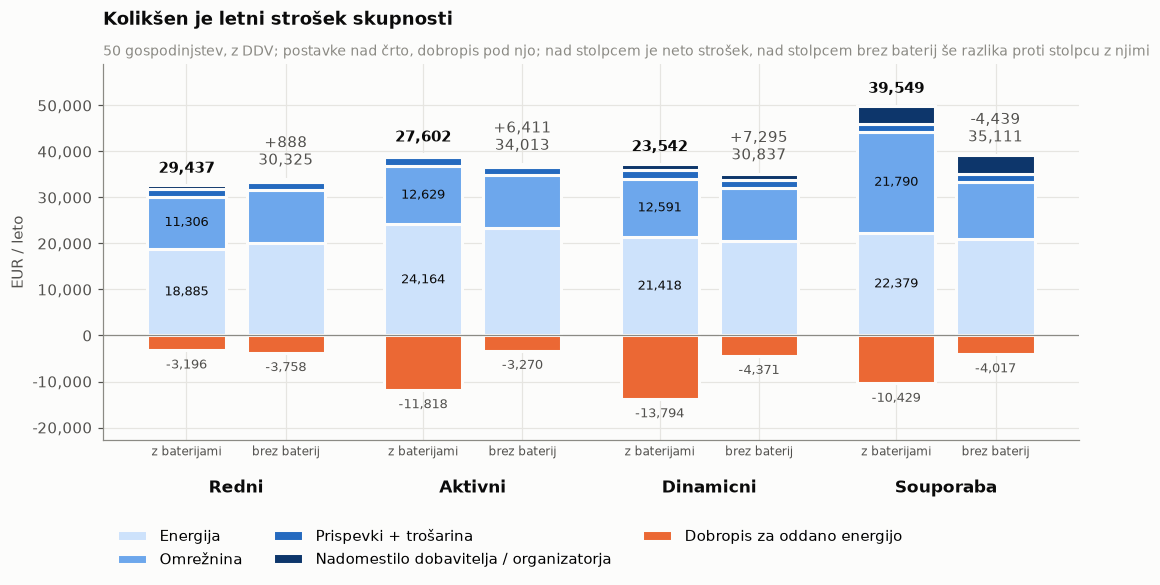

,Scenario,Z baterijami [EUR],Brez baterij [EUR],Razlika [EUR],Razlika [%],Omrežnina z baterijami [EUR],Omrežnina brez [EUR],Dobropis z baterijami [EUR],Dobropis brez [EUR]
0,Redni,29437.4,30324.9,887.5,2.9,11306.0,11546.9,3196.4,3757.6
1,Aktivni,27601.8,34013.1,6411.3,18.8,12628.6,11546.9,11818.2,3270.0
2,Dinamicni,23542.4,30837.0,7294.6,23.7,12590.8,11546.9,13794.4,4371.0
3,Souporaba,39549.4,35110.6,-4438.8,-12.6,21790.2,12434.2,10429.3,4016.9


In [17]:
### Community annual cost by scenario, with the batteries and without them
resid = max(TOTALS["Category_Residual_EUR"].abs().max(),
            TOTALS_BASE["Category_Residual_EUR"].abs().max())
print(f"Supply + network + levies + fees - credit reproduces the billed total to {resid:.2e} EUR")
# A tenth of a cent: eight items per interval across 50 households and a year.
assert resid < 1e-3, "the cost split does not reconcile with the billed total"

# The bars are drawn by position, so the baseline is reordered explicitly.
BASE = TOTALS_BASE.set_index("scenario").loc[TOTALS["scenario"]].reset_index()

# Network and energy are the two halves worth telling apart: the network side is
# regulated, the energy side is what a package competes on.
parts = [
    ("Supply_EUR", "Energija", BLUES[0]),
    ("Network_EUR", "Omrežnina", BLUES[2]),
    ("Levies_EUR", "Prispevki + trošarina", BLUES[4]),
    ("Supplier_Fee_EUR", "Nadomestilo dobavitelja / organizatorja", BLUES[6]),
]

# Each scenario is drawn twice, with and without batteries. Colour means "which
# item is being paid" in both stacks; the pair is told apart by position.
fig, ax = plt.subplots(figsize=(11, 5.6))
x = np.arange(len(TOTALS))
width, off = 0.33, 0.21

def stacked(frame, offset, in_slice, legend):
    """One stack per scenario at `offset`; returns the top of each gross stack."""
    bottom = np.zeros(len(frame))
    gross = frame["Gross_EUR"].to_numpy(dtype=float)
    for col, label, color in parts:
        vals = frame[col].fillna(0.0).to_numpy(dtype=float)
        ax.bar(x + offset, vals, bottom=bottom, width=width,
               label=label if legend else None,
               color=color, edgecolor=SURFACE, linewidth=2)
        if in_slice:
            # In-slice figure only where the slice is tall enough to hold it.
            for xi, val, base, tot in zip(x + offset, vals, bottom, gross):
                if val > 0.09 * tot:
                    ax.annotate(f"{val:,.0f}", (xi, base + val / 2), ha="center",
                                va="center", fontsize=8.5,
                                color=SURFACE if color in BLUES[4:] else INK)
        bottom += vals
    credit = -frame["Credit_EUR"].fillna(0.0).to_numpy(dtype=float)
    ax.bar(x + offset, credit, width=width, color=SERIES[1], edgecolor=SURFACE,
           linewidth=2, label="Dobropis za oddano energijo" if legend else None)
    for xi, val in zip(x + offset, credit):
        ax.annotate(f"{val:,.0f}", (xi, val), xytext=(0, -12), textcoords="offset points",
                    ha="center", fontsize=8.5, color=INK_2)
    return bottom

top_batt = stacked(TOTALS, -off, in_slice=True, legend=True)
top_base = stacked(BASE, +off, in_slice=False, legend=False)

delta = BASE["Total_EUR"].to_numpy(dtype=float) - TOTALS["Total_EUR"].to_numpy(dtype=float)
for xi, y, total in zip(x - off, top_batt, TOTALS["Total_EUR"]):
    ax.annotate(f"{total:,.0f}", (xi, y), xytext=(0, 6), textcoords="offset points",
                ha="center", va="bottom", fontsize=9.5, fontweight="semibold", color=INK)
for xi, y, total, d in zip(x + off, top_base, BASE["Total_EUR"], delta):
    ax.annotate(f"{d:+,.0f}\n{total:,.0f}", (xi, y), xytext=(0, 6),
                textcoords="offset points", ha="center", va="bottom", fontsize=9.5,
                color=INK_2)

ax.axhline(0, color=MUTED, linewidth=0.8)
# Two levels on the x axis: which bill under the bar, which scenario under the pair.
ax.set_xticks(np.concatenate([x - off, x + off]))
ax.set_xticklabels(["z baterijami"] * len(x) + ["brez baterij"] * len(x),
                   fontsize=8, color=INK_2)
ax.tick_params(axis="x", length=0)
for xi, name in zip(x, TOTALS["Scenario"]):
    ax.text(xi, -0.105, name, transform=ax.get_xaxis_transform(), ha="center",
            va="top", fontsize=11, fontweight="semibold", color=INK)
ax.yaxis.set_major_formatter(EUR)
ax.margins(y=0.14)
ax.legend(ncol=3, loc="upper left", bbox_to_anchor=(0, -0.20))
finish(ax, "Kolikšen je letni strošek skupnosti",
       f"{len(MEMBERS)} gospodinjstev, z DDV; postavke nad črto, dobropis pod njo; "
       f"nad stolpcem je neto strošek, nad stolpcem brez baterij še razlika proti "
       f"stolpcu z njimi",
       ylabel="EUR / leto")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "Scenario": TOTALS["Scenario"],
    "Z baterijami [EUR]": TOTALS["Total_EUR"],
    "Brez baterij [EUR]": BASE["Total_EUR"],
    "Razlika [EUR]": delta,
    "Razlika [%]": 100 * delta / BASE["Total_EUR"],
    "Omrežnina z baterijami [EUR]": TOTALS["Network_EUR"],
    "Omrežnina brez [EUR]": BASE["Network_EUR"],
    "Dobropis z baterijami [EUR]": TOTALS["Credit_EUR"],
    "Dobropis brez [EUR]": BASE["Credit_EUR"],
}).round(1)

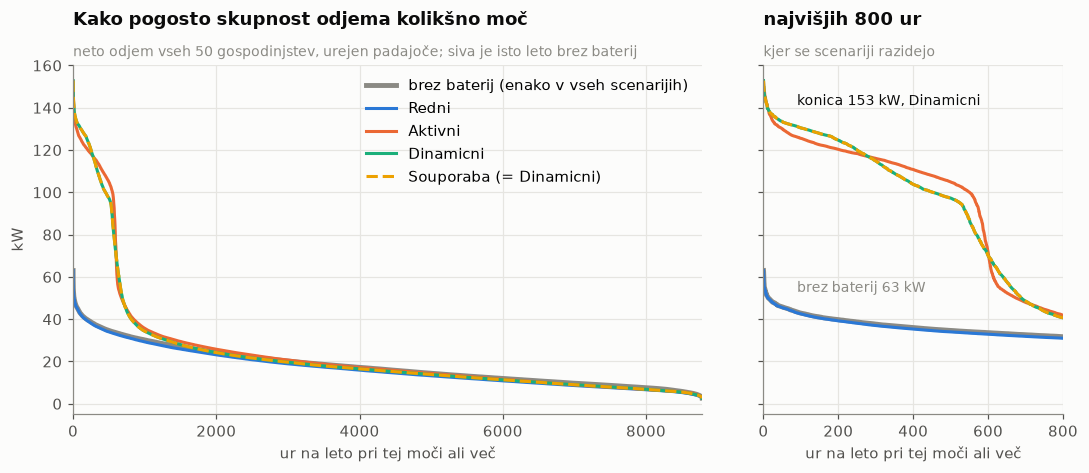

,Scenario,presežena 1 h [kW],presežena 10 h [kW],presežena 100 h [kW],presežena 800 h [kW]
0,Redni,59.1,50.7,42.5,31.0
1,Aktivni,150.1,141.4,125.5,41.8
2,Dinamicni,149.9,140.7,130.4,40.7
3,Souporaba,149.9,140.7,130.4,40.7
4,Brez baterij,59.1,51.0,42.9,31.7


In [18]:
### Community net-import duration curve, against the same year with no batteries
ZOOM_HOURS = 800
interval_hours = 24.0 / cs.STEPS_PER_DAY

fig, (ax, axz) = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True,
                              gridspec_kw={"width_ratios": [2.1, 1]})

# The baseline is a reference, not a fifth scenario, so it is drawn underneath
# in ink. One curve covers all four scenarios (asserted in section 4).
base_sorted = np.sort(BASE_PROFILE["community_import_kw"].to_numpy(dtype=float))[::-1]
base_hours = (np.arange(len(base_sorted)) + 1) * interval_hours
ax.plot(base_hours, base_sorted, color=MUTED, linewidth=3.2, zorder=1,
        label="brez baterij (enako v vseh scenarijih)")
axz.plot(base_hours, base_sorted, color=MUTED, linewidth=3.2, zorder=1)

for scenario in SCEN_ORDER:
    profile = RESULTS[scenario]["community_profile"]["community_import_kw"]
    sorted_kw = np.sort(profile.to_numpy(dtype=float))[::-1]
    hours = (np.arange(len(sorted_kw)) + 1) * interval_hours
    # Souporaba runs the dinamicni dispatch, so its curve lies on top of it.
    style = {"color": SCEN_COLOR[scenario], "linewidth": 2, "zorder": 2,
             "linestyle": "--" if scenario == "souporaba" else "-"}
    label = LABEL[scenario] + (" (= Dinamicni)" if scenario == "souporaba" else "")
    ax.plot(hours, sorted_kw, label=label, **style)
    axz.plot(hours, sorted_kw, **style)

peak_row = TOTALS.loc[TOTALS["Community_Peak_kW"].idxmax()]
axz.annotate(f"konica {peak_row['Community_Peak_kW']:.0f} kW, {peak_row['Scenario']}",
             (0, peak_row["Community_Peak_kW"]), xytext=(22, -16),
             textcoords="offset points", color=INK, fontsize=9)
axz.annotate(f"brez baterij {base_sorted[0]:.0f} kW",
             (0, base_sorted[0]), xytext=(22, -14),
             textcoords="offset points", color=MUTED, fontsize=9)

ax.set_xlim(0, 8784)
ax.set_xticks(np.arange(0, 8785, 2000))
ax.legend(loc="upper right")
finish(ax, "Kako pogosto skupnost odjema kolikšno moč",
       "neto odjem vseh 50 gospodinjstev, urejen padajoče; siva je isto leto brez baterij",
       xlabel="ur na leto pri tej moči ali več", ylabel="kW")

axz.set_xlim(0, ZOOM_HOURS)
axz.set_xticks(np.arange(0, ZOOM_HOURS + 1, 200))
finish(axz, f"najvišjih {ZOOM_HOURS} ur", "kjer se scenariji razidejo",
       xlabel="ur na leto pri tej moči ali več")
plt.tight_layout()
plt.show()

# The power exceeded 1, 10, 100 and 800 hours a year.
top_hours = [1, 10, 100, ZOOM_HOURS]

def top_of_curve(sorted_kw, label):
    return {"Scenario": label,
            **{f"presežena {h} h [kW]": sorted_kw[int(h / interval_hours) - 1]
               for h in top_hours}}

rows = [top_of_curve(
    np.sort(RESULTS[s]["community_profile"]["community_import_kw"].to_numpy(dtype=float))[::-1],
    LABEL[s],
) for s in SCEN_ORDER]
rows.append(top_of_curve(base_sorted, "Brez baterij"))
pd.DataFrame(rows).round(1)

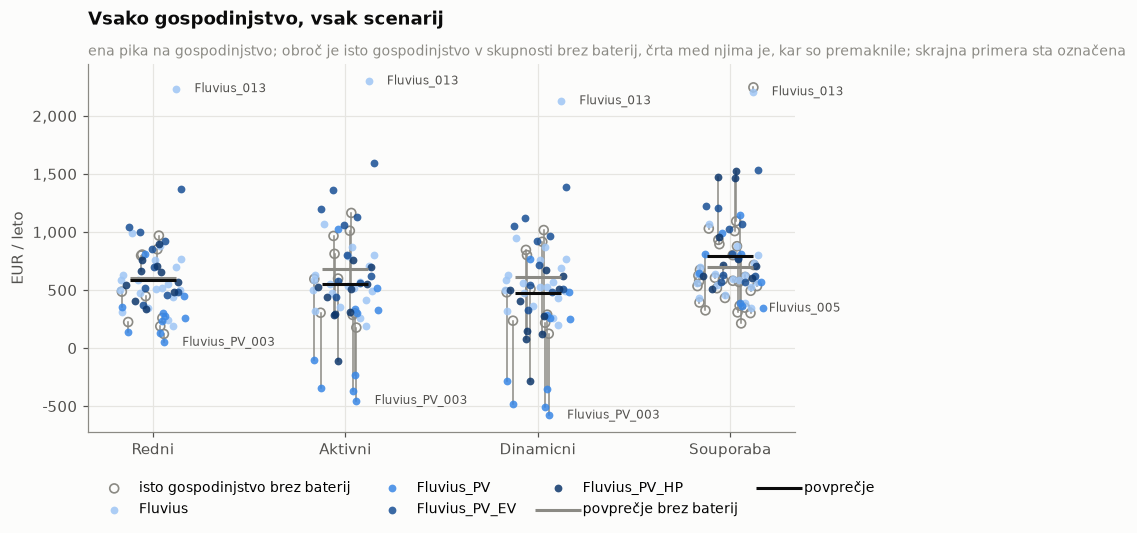

Premik > 0 pomeni, da bi gospodinjstvo brez baterij v skupnosti plačalo več.


count   mean    min    max     sum
Scenario  Baterija                                         
Redni     brez baterije     40    0.0    0.0    0.0     0.0
          z baterijo        10   88.8   27.9  141.0   887.5
Aktivni   brez baterije     40    0.0    0.0    0.0     0.0
          z baterijo        10  641.1  516.9  708.5  6411.3
Dinamicni brez baterije     40    0.0    0.0    0.0     0.0
          z baterijo        10  729.5  637.2  790.7  7294.6
Souporaba brez baterije     40  -10.3  -42.2   38.5  -410.3
          z baterijo        10 -402.9 -784.6  -65.0 -4028.5

In [19]:
### Per-household annual cost, by scenario, against the same year with no batteries
fig, ax = plt.subplots(figsize=(9.5, 5.0))
rng = np.random.default_rng(0)

# One jitter per household, reused in every column, so the with/without pair
# reads as one vertical segment.
ids = sorted(HOUSEHOLDS["household_id"].unique())
JITTER = dict(zip(ids, rng.uniform(-0.17, 0.17, len(ids))))

BASE_COST = HOUSEHOLDS_BASE.set_index(["scenario", "household_id"])["total_cost_eur"]
MOVED_EUR = 1.0   # below this the ring lands on the dot and says nothing

for i, scenario in enumerate(SCEN_ORDER):
    subset = HOUSEHOLDS[HOUSEHOLDS["scenario"] == scenario]
    cost = subset.set_index("household_id")["total_cost_eur"]
    base = BASE_COST[scenario].reindex(cost.index)

    # A ring wherever removing the batteries moves the bill by over a euro: the
    # ten battery households under redni/aktivni/dinamicni, all fifty under
    # souporaba, where the senders' surplus changes every receiver's share.
    moved = base[(base - cost).abs() > MOVED_EUR]
    for hid in moved.index:
        xb = i + JITTER[hid]
        ax.plot([xb, xb], [base[hid], cost[hid]], color=MUTED, linewidth=1, zorder=1)
    ax.scatter([i + JITTER[h] for h in moved.index], moved.to_numpy(dtype=float),
               s=34, facecolor="none", edgecolor=MUTED, linewidth=1.1, zorder=2,
               label="isto gospodinjstvo brez baterij" if i == 0 else None)

    for seg in SEGMENTS:
        seg_rows = subset[subset["segment"] == seg]
        ax.scatter([i + JITTER[h] for h in seg_rows["household_id"]],
                   seg_rows["total_cost_eur"], s=26, color=SEG_COLOR[seg],
                   alpha=0.85, linewidth=0, zorder=3, label=seg if i == 0 else None)

    ax.scatter([i], [base.mean()], marker="_", s=900, color=MUTED, linewidth=2,
               zorder=4, label="povprečje brez baterij" if i == 0 else None)
    ax.scatter([i], [cost.mean()], marker="_", s=900, color=INK, linewidth=2,
               zorder=5, label="povprečje" if i == 0 else None)

for _, row in EXTREMES.iterrows():
    xi = SCEN_ORDER.index(row["scenario"]) + JITTER[row["household_id"]]
    ax.annotate(row["household_id"], (xi, row["Cost_EUR"]), xytext=(12, 0),
                textcoords="offset points", fontsize=8, color=INK_2, va="center")

ax.set_xticks(range(len(SCEN_ORDER)))
ax.set_xticklabels([LABEL[s] for s in SCEN_ORDER])
ax.yaxis.set_major_formatter(EUR)
ax.legend(ncol=4, loc="upper left", bbox_to_anchor=(0, -0.10), fontsize=9)
finish(ax, "Vsako gospodinjstvo, vsak scenarij",
       "ena pika na gospodinjstvo; obroč je isto gospodinjstvo v skupnosti brez baterij, "
       "črta med njima je, kar so premaknile; skrajna primera sta označena",
       ylabel="EUR / leto")
plt.tight_layout()
plt.show()

# What the ten batteries moved, on their own bills and on everybody else's.
moved_all = HOUSEHOLDS[["scenario", "household_id", "battery_kwh", "total_cost_eur"]].copy()
moved_all["Brez baterij [EUR]"] = [
    BASE_COST[(s, h)] for s, h in zip(moved_all["scenario"], moved_all["household_id"])
]
moved_all["Premik [EUR]"] = moved_all["Brez baterij [EUR]"] - moved_all["total_cost_eur"]
moved_all["Scenario"] = moved_all["scenario"].map(LABEL)
moved_all["Baterija"] = np.where(moved_all["battery_kwh"] > 0, "z baterijo", "brez baterije")
print("Premik > 0 pomeni, da bi gospodinjstvo brez baterij v skupnosti plačalo več.")
moved_all.groupby(["Scenario", "Baterija"], sort=False)["Premik [EUR]"].agg(
    ["count", "mean", "min", "max", "sum"]).round(1)

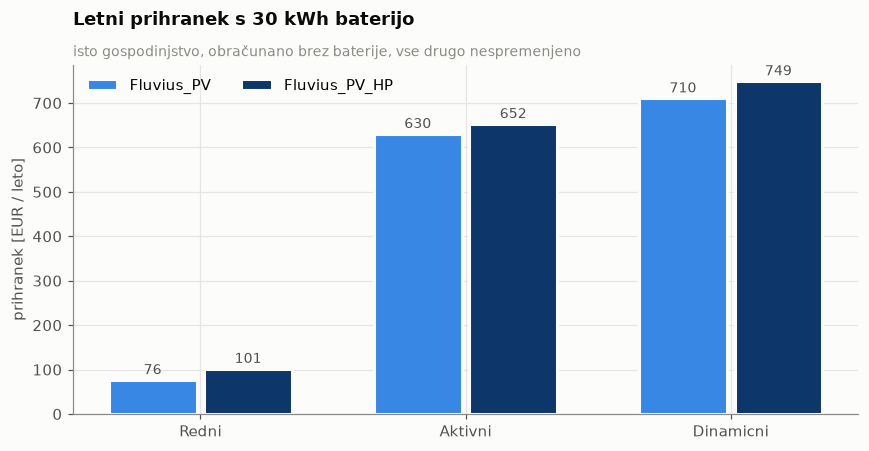

In [20]:
### What the 30 kWh battery is worth
fig, ax = plt.subplots(figsize=(8, 4.2))

saving = COUNTERFACTUAL.groupby(["Scenario", "segment"])["Saving_EUR"].mean().unstack()
saving = saving.reindex([cs.SCENARIOS[s]["label"] for s in SCEN_ORDER if s != "souporaba"])
x = np.arange(len(saving))
width = 0.36

for i, seg in enumerate(saving.columns):
    ax.bar(x + (i - 0.5) * width, saving[seg], width=width * 0.92,
           color=SEG_COLOR[seg], edgecolor=SURFACE, linewidth=2, label=seg)
    for xi, val in zip(x + (i - 0.5) * width, saving[seg]):
        ax.annotate(f"{val:,.0f}", (xi, val), xytext=(0, 4),
                    textcoords="offset points", ha="center", fontsize=9, color=INK_2)

ax.set_xticks(x)
ax.set_xticklabels(saving.index)
ax.yaxis.set_major_formatter(EUR)
ax.legend(ncol=2, loc="upper left")
finish(ax, "Letni prihranek s 30 kWh baterijo",
       "isto gospodinjstvo, obračunano brez baterije, vse drugo nespremenjeno",
       ylabel="prihranek [EUR / leto]")
plt.tight_layout()
plt.show()

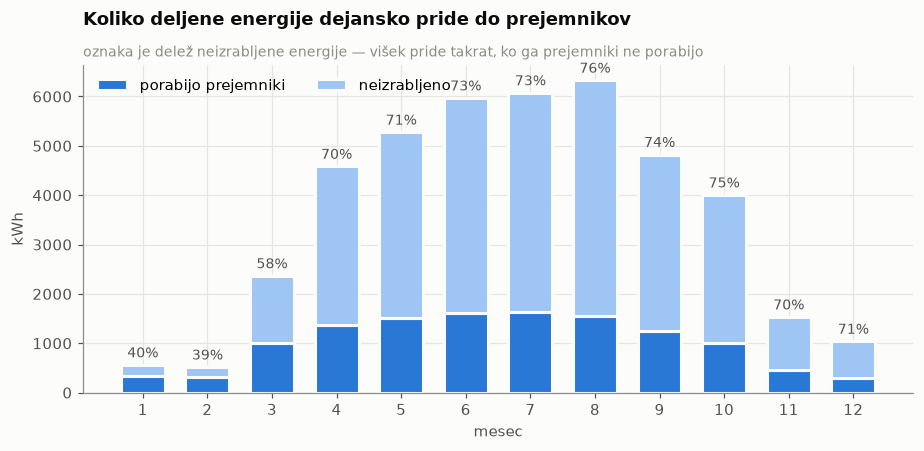

In [21]:
### Souporaba: shared energy used vs forfeited, by month
monthly = RESULTS["souporaba"]["monthly"]
recv = monthly[monthly["role"] == "prejemnik"].groupby("month")[
    ["deljeno_kwh", "neizrabljeno_kwh"]
].sum()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(recv.index, recv["deljeno_kwh"], width=0.68, color=SERIES[0],
       edgecolor=SURFACE, linewidth=2, label="porabijo prejemniki")
ax.bar(recv.index, recv["neizrabljeno_kwh"], bottom=recv["deljeno_kwh"], width=0.68,
       color=BLUES[1], edgecolor=SURFACE, linewidth=2, label="neizrabljeno")

share = 100 * recv["neizrabljeno_kwh"] / (recv["deljeno_kwh"] + recv["neizrabljeno_kwh"])
for m, pct in share.items():
    total = recv.loc[m].sum()
    ax.annotate(f"{pct:.0f}%", (m, total), xytext=(0, 5), textcoords="offset points",
                ha="center", fontsize=9, color=INK_2)

ax.set_xticks(range(1, 13))
ax.legend(ncol=2, loc="upper left")
finish(ax, "Koliko deljene energije dejansko pride do prejemnikov",
       "oznaka je delež neizrabljene energije — višek pride takrat, ko ga prejemniki ne porabijo",
       xlabel="mesec", ylabel="kWh")
plt.tight_layout()
plt.show()

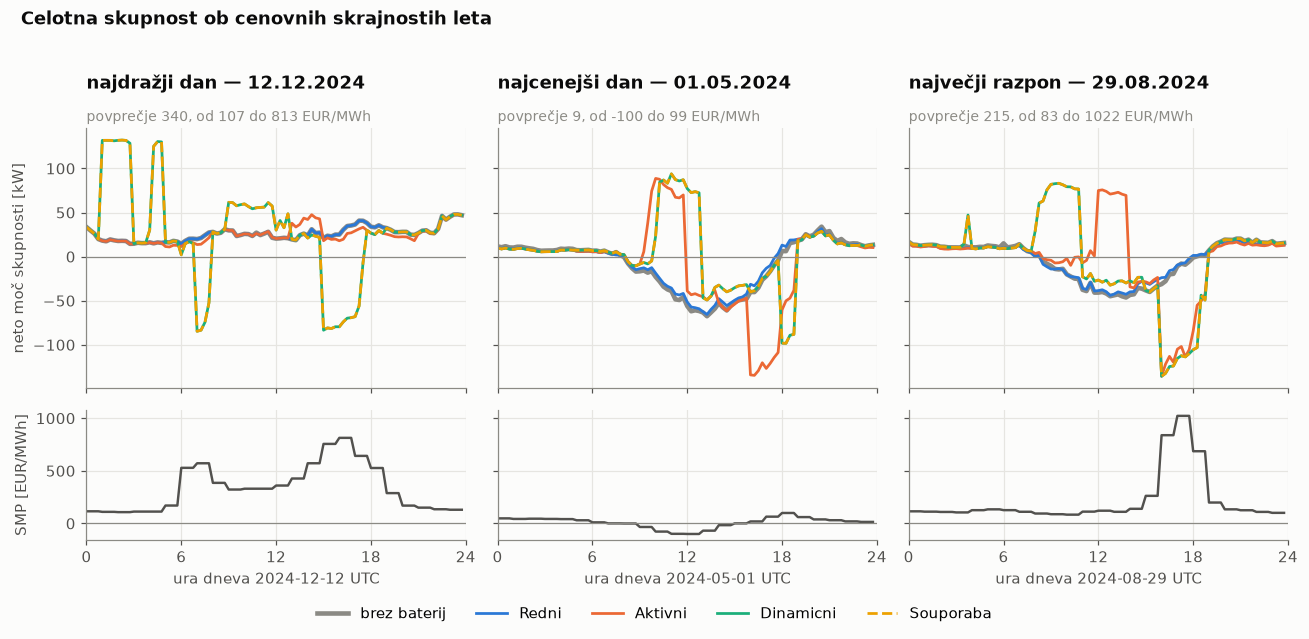

,mean,min,max,range,day
Timestamp_UTC,,,,,
2024-12-12 00:00:00+00:00,340.2,107.4,813.3,705.9,najdražji dan
2024-05-01 00:00:00+00:00,8.7,-100.2,99.3,199.6,najcenejši dan
2024-08-29 00:00:00+00:00,215.1,83.4,1022.3,938.9,največji razpon


In [22]:
### The whole community on the year's price extremes
# Read off the community profile's own index so the slicing stays positional:
# the Fluvius files repeat the DST fall-back hour, so labels are duplicated.
ref_index = RESULTS[SCEN_ORDER[0]]["community_profile"].index
smp = pd.Series(
    next(iter(DATA.values()))[cs.PRICE_COLUMN].to_numpy(dtype=float)[: len(ref_index)] * 1000.0,
    index=ref_index,
)
day_of = ref_index.normalize()
daily = smp.groupby(day_of).agg(["mean", "min", "max"])
daily["range"] = daily["max"] - daily["min"]

# Dearest and cheapest by daily mean; the swing is the intra-day range, which is
# what a battery earns on. Ties take the runner-up, so the days always differ.
picks = []
for label, column, ascending in [("najdražji dan", "mean", False),
                                 ("najcenejši dan", "mean", True),
                                 ("največji razpon", "range", False)]:
    order = daily[column].sort_values(ascending=ascending).index
    picks.append((label, next(d for d in order if d not in [p[1] for p in picks])))

# Souporaba is dispatched by the Dinamicni solve (cs.DISPATCH_ALIAS) and
# settlement leaves no mark on a power chart, so the curve is drawn once.
FLOW_SCEN = [s for s in SCEN_ORDER if s not in cs.DISPATCH_ALIAS]
SHARES_DISPATCH = {}
for alias, target in cs.DISPATCH_ALIAS.items():
    SHARES_DISPATCH.setdefault(target, []).append(LABEL[alias])
FLOW_LABEL = {s: " = ".join([LABEL[s]] + SHARES_DISPATCH.get(s, [])) for s in FLOW_SCEN}

interval_hours = 24.0 / cs.STEPS_PER_DAY
MARK_EVERY = cs.STEPS_PER_DAY // 12      # an open circle every two hours
fig, axes = plt.subplots(2, 3, figsize=(12, 5.8), sharex="col", sharey="row",
                         gridspec_kw={"height_ratios": [2, 1]})

def net_kw(profile, mask):
    """Net position of the community as a whole: everyone's import minus
    everyone's export, so PV feeding a neighbour nets out instead of counting
    twice."""
    window = profile.loc[mask]
    return (window["community_import_kwh"].to_numpy(dtype=float)
            - window["community_export_kwh"].to_numpy(dtype=float)) / interval_hours

for col, (label, day) in enumerate(picks):
    ax, axp = axes[0, col], axes[1, col]
    mask = (ref_index >= day) & (ref_index < day + pd.Timedelta(days=1))
    hours = (ref_index[mask] - day).total_seconds() / 3600.0

    # The unbatteried day underneath, in ink rather than a fourth hue, with open
    # circles every two hours so it stays followable under the crossing lines.
    ax.plot(hours, net_kw(BASE_PROFILE, mask), color=MUTED, linewidth=3, zorder=1,
            marker="o", markevery=MARK_EVERY, markersize=6,
            markerfacecolor=SURFACE, markeredgewidth=1.6,
            label="brez baterij" if col == 0 else None)
    for scenario in FLOW_SCEN:
        ax.plot(hours, net_kw(RESULTS[scenario]["community_profile"], mask),
                color=SCEN_COLOR[scenario], linewidth=1.8, zorder=2,
                label=FLOW_LABEL[scenario] if col == 0 else None)

    ax.axhline(0, color=MUTED, linewidth=0.8)
    row = daily.loc[day]
    finish(ax, f"{label} — {day:%d.%m.%Y}",
           f"povprečje {row['mean']:.0f}, od {row['min']:.0f} do {row['max']:.0f} EUR/MWh",
           ylabel="neto moč skupnosti [kW]" if col == 0 else None)

    axp.plot(hours, smp.loc[mask].to_numpy(dtype=float), color=INK_2, linewidth=1.6)
    axp.axhline(0, color=MUTED, linewidth=0.8)
    axp.set_xlim(0, 24)
    axp.set_xticks([0, 6, 12, 18, 24])
    axp.set_xlabel(f"ura dneva {day:%Y-%m-%d} UTC")
    if col == 0:
        axp.set_ylabel("SMP [EUR/MWh]")

# Figure-level legend: these panels are full from top to bottom.
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(FLOW_SCEN) + 1, loc="lower center",
           bbox_to_anchor=(0.5, 0.0))
fig.suptitle("Celotna skupnost ob cenovnih skrajnostih leta", x=0.02, ha="left",
             fontsize=12, fontweight="semibold", color=INK)
plt.tight_layout(rect=(0, 0.05, 1, 0.96))
plt.show()

daily.loc[[d for _, d in picks]].assign(day=[l for l, _ in picks]).round(1)

## 9. Read-out

In [23]:
### The whole study in one block of text
lines = []
best = TOTALS.loc[TOTALS["Total_EUR"].idxmin()]
worst = TOTALS.loc[TOTALS["Total_EUR"].idxmax()]
gap_eur = best["Total_EUR"] * cs.hc.FULL_PERIOD_GAP_REL

lines.append(f"COMMUNITY OF {len(MEMBERS)} HOUSEHOLDS, YEAR {next(iter(DATA.values())).index[0]:%Y}")
lines.append("")
lines.append(f"{'scenario':14s}{'EUR/a':>11s}{'EUR/MWh':>10s}{'peak kW':>10s}{'diversity':>11s}")
for _, row in TOTALS.iterrows():
    lines.append(f"{row['Scenario']:14s}{row['Total_EUR']:11,.0f}"
                 f"{row['EUR_per_MWh']:10.1f}{row['Community_Peak_kW']:10.1f}"
                 f"{row['Diversity_Factor']:11.2f}")
lines.append("")
lines.append(f"Cheapest: {best['Scenario']} at {best['Total_EUR']:,.0f} EUR/a.")
lines.append(f"Dearest:  {worst['Scenario']} at {worst['Total_EUR']:,.0f} EUR/a "
             f"(+{worst['Total_EUR'] - best['Total_EUR']:,.0f} EUR, "
             f"{100 * (worst['Total_EUR'] / best['Total_EUR'] - 1):.1f} %).")

close = TOTALS[abs(TOTALS["Total_EUR"] - best["Total_EUR"]) < gap_eur]
if len(close) > 1:
    lines.append(f"NOT RESOLVABLE: {', '.join(close['Scenario'])} land within the solver's "
                 f"{cs.hc.FULL_PERIOD_GAP_REL:.1%} gap ({gap_eur:,.0f} EUR) of each other.")

lines.append("")
lines.append("PEAK POWER")
pk = TOTALS.loc[TOTALS["Community_Peak_kW"].idxmax()]
lines.append(f"  Highest coincident peak {pk['Community_Peak_kW']:.1f} kW "
             f"under {pk['Scenario']}, at {pk['Peak_At']:%Y-%m-%d %H:%M} UTC.")
lines.append(f"  The 50 individual peaks sum to {pk['Sum_Individual_Peaks_kW']:.0f} kW, so the "
             f"community draws only {pk['Diversity_Factor']:.0%} of what its members are")
lines.append(f"  billed for -- the power charge is levied per household, not on this peak.")
lo = TOTALS.loc[TOTALS["Community_Peak_kW"].idxmin()]
lines.append(f"  Tariff choice moves the peak more than anything else here: {lo['Scenario']} peaks at "
             f"{lo['Community_Peak_kW']:.0f} kW,")
lines.append(f"  {pk['Scenario']} at {pk['Community_Peak_kW']:.0f} kW -- "
             f"{pk['Community_Peak_kW'] / lo['Community_Peak_kW']:.1f}x. Under a flat tariff the battery only")
lines.append(f"  shaves; under a price-following one it charges hard from the grid when energy is")
lines.append(f"  cheap. Ten 11 kW inverters acting together is worth ~110 kW of new peak, and the")
lines.append(f"  excess-power charge is not steep enough to stop them.")

lines.append("")
lines.append("EXTREMES")
for _, row in EXTREMES.iterrows():
    driver = []
    if row["Battery_kWh"] > 0:
        driver.append(f"{row['Battery_kWh']:.0f} kWh battery")
    if row["Produced_kWh"] > 0:
        driver.append(f"{row['Produced_kWh']:,.0f} kWh PV")
    else:
        driver.append("no PV")
    driver.append(f"peak {row['Peak_over_Contract']:.1f}x contract")
    lines.append(f"  {row['Scenario']:11s} {row['Extreme']:8s} {row['household_id']:20s}"
                 f"{row['Cost_EUR']:8,.0f} EUR  ({row['Consumed_kWh']:,.0f} kWh load, "
                 f"{', '.join(driver)})")

lines.append("")
lines.append("BATTERY")
for scen, grp in COUNTERFACTUAL.groupby("Scenario", sort=False):
    lines.append(f"  {scen:11s} mean saving {grp['Saving_EUR'].mean():7,.0f} EUR/a "
                 f"(range {grp['Saving_EUR'].min():,.0f} to {grp['Saving_EUR'].max():,.0f})")

lines.append("")
lines.append("SOUPORABA")
lines.append(f"  {shared:,.0f} kWh shared, {used:,.0f} kWh used ({100 * used / shared:.0f} %), "
             f"{wasted:,.0f} kWh forfeited.")
sou_total = float(TOTALS.loc[TOTALS['scenario'] == 'souporaba', 'Total_EUR'].iloc[0])
din_total = float(TOTALS.loc[TOTALS['scenario'] == 'dinamicni', 'Total_EUR'].iloc[0])
lines.append(f"  Against the same dispatch on plain Dinamični: "
             f"{sou_total - din_total:+,.0f} EUR/a for the community.")
lines.append(f"  Receivers pay for every kWh transferred, used or not "
             f"(placilo_za_neizrabljeno=True):")
lines.append(f"    {wasted:,.0f} kWh forfeited x {cs.SOUPORABA_CENA_EUR_KWH} EUR/kWh"
             f" = {wasted * cs.SOUPORABA_CENA_EUR_KWH:,.0f} EUR paid for energy that never landed.")
n_send = int((sou_members['role'] == 'oddajnik').sum())
n_recv = int((sou_members['role'] == 'prejemnik').sum())
svc = cs.STORITVE_SOUPORABE[cs.SOUPORABA_SERVICE_ID]
fees = 12 * (n_send * svc.nadomestilo_oddajnik + n_recv * svc.nadomestilo_prejemnik)
lines.append(f"    organizer fees {n_send} x {svc.nadomestilo_oddajnik} + "
             f"{n_recv} x {svc.nadomestilo_prejemnik} EUR/month = {fees:,.0f} EUR/a.")
lines.append(f"  The rest is senders giving up the market buyback on the shared 40 %.")

print("\n".join(lines))

COMMUNITY OF 50 HOUSEHOLDS, YEAR 2024

scenario            EUR/a   EUR/MWh   peak kW  diversity
Redni              29,437     184.7      63.0       0.21
Aktivni            27,602     173.2     152.5       0.41
Dinamicni          23,542     147.7     152.8       0.40
Souporaba          39,549     248.2     152.8       0.40

Cheapest: Dinamicni at 23,542 EUR/a.
Dearest:  Souporaba at 39,549 EUR/a (+16,007 EUR, 68.0 %).

PEAK POWER
  Highest coincident peak 152.8 kW under Dinamicni, at 2024-01-29 00:00 UTC.
  The 50 individual peaks sum to 386 kW, so the community draws only 40% of what its members are
  billed for -- the power charge is levied per household, not on this peak.
  Tariff choice moves the peak more than anything else here: Redni peaks at 63 kW,
  Dinamicni at 153 kW -- 2.4x. Under a flat tariff the battery only
  shaves; under a price-following one it charges hard from the grid when energy is
  cheap. Ten 11 kW inverters acting together is worth ~110 kW of new peak, and the


### Caveats

- **The MILP optimizes each battery household against its own bill**, not the community's.
  The souporaba figures are a settlement laid on a selfishly-optimized dispatch.
- **No shared community battery.** The only storage is the ten household batteries.
- **Battery households report zero `lastna_raba_kwh`** — the trajectory reaches the
  settlement as an equivalent pair reproducing the net flow, so the bill is exact but the
  self-consumption diagnostic is not recoverable.
- **Two excess-power formulas coexist**: the MILP objective uses the `si_konica` ratchet, the
  invoices the regulated monthly `sqrt(sum d^2)`. It affects the excess-power line only.
- **2024 data, 2026 tariffs** (`PRICING_REFERENCE_YEAR = 2026`).